<a href="https://colab.research.google.com/github/weathon/neg/blob/main/SD3_5_turbo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from diffusers import StableDiffusion3Pipeline

pipe = StableDiffusion3Pipeline.from_pretrained("stabilityai/stable-diffusion-3.5-large-turbo", torch_dtype=torch.bfloat16)
pipe = pipe.to("cuda")

  0%|          | 0/4 [00:00<?, ?it/s]

In [209]:
import inspect
import math
from typing import Callable, List, Optional, Tuple, Union

import torch
import torch.nn.functional as F
from torch import nn

from diffusers.image_processor import IPAdapterMaskProcessor
from diffusers.utils import deprecate, is_torch_xla_available, logging
from diffusers.utils.import_utils import is_torch_npu_available, is_torch_xla_version, is_xformers_available
from diffusers.utils.torch_utils import is_torch_version, maybe_allow_in_graph
from diffusers.models.attention_processor import (
    Attention
)

logger = logging.get_logger(__name__)  # pylint: disable=invalid-name

if is_torch_npu_available():
    import torch_npu

if is_xformers_available():
    import xformers
    import xformers.ops
else:
    xformers = None

if is_torch_xla_available():
    # flash attention pallas kernel is introduced in the torch_xla 2.3 release.
    if is_torch_xla_version(">", "2.2"):
        from torch_xla.experimental.custom_kernel import flash_attention
        from torch_xla.runtime import is_spmd
    XLA_AVAILABLE = True
else:
    XLA_AVAILABLE = False

class JointAttnProcessor2_0:
    """Attention processor used typically in processing the SD3-like self-attention projections."""

    def __init__(self):
        if not hasattr(F, "scaled_dot_product_attention"):
            raise ImportError("JointAttnProcessor2_0 requires PyTorch 2.0, to use it, please upgrade PyTorch to 2.0.")

    def __call__(
        self,
        attn: Attention,
        hidden_states: torch.FloatTensor,
        encoder_hidden_states: torch.FloatTensor = None,
        attention_mask: Optional[torch.FloatTensor] = None,
        *args,
        **kwargs,
    ) -> torch.FloatTensor:
        residual = hidden_states

        batch_size = hidden_states.shape[0]

        query = attn.to_q(hidden_states)
        key = attn.to_k(hidden_states)
        value = attn.to_v(hidden_states)

        inner_dim = key.shape[-1]
        head_dim = inner_dim // attn.heads

        query = query.view(batch_size, -1, attn.heads, head_dim).transpose(1, 2)
        key = key.view(batch_size, -1, attn.heads, head_dim).transpose(1, 2)
        value = value.view(batch_size, -1, attn.heads, head_dim).transpose(1, 2)

        if attn.norm_q is not None:
            query = attn.norm_q(query)
        if attn.norm_k is not None:
            key = attn.norm_k(key)
        attn_mask = None
        if encoder_hidden_states is not None:
            encoder_hidden_states_query_proj = attn.add_q_proj(encoder_hidden_states)
            encoder_hidden_states_key_proj = attn.add_k_proj(encoder_hidden_states)
            encoder_hidden_states_value_proj = attn.add_v_proj(encoder_hidden_states)

            encoder_hidden_states_query_proj = encoder_hidden_states_query_proj.view(
                batch_size, -1, attn.heads, head_dim
            ).transpose(1, 2)
            encoder_hidden_states_key_proj = encoder_hidden_states_key_proj.view(
                batch_size, -1, attn.heads, head_dim
            ).transpose(1, 2)
            encoder_hidden_states_value_proj = encoder_hidden_states_value_proj.view(
                batch_size, -1, attn.heads, head_dim
            ).transpose(1, 2)

            if attn.norm_added_q is not None:
                encoder_hidden_states_query_proj = attn.norm_added_q(encoder_hidden_states_query_proj)
            if attn.norm_added_k is not None:
                encoder_hidden_states_key_proj = attn.norm_added_k(encoder_hidden_states_key_proj)

            query = torch.cat([query, encoder_hidden_states_query_proj], dim=2)
            key = torch.cat([key, encoder_hidden_states_key_proj], dim=2)
            value = torch.cat([value, encoder_hidden_states_value_proj], dim=2)
            value[:,:,-154:] *= -0.3
            attn_mask = torch.zeros((query.shape[0], query.shape[-2], value.shape[-2])).cuda().bfloat16()
            attn_mask[:,-154:,-154:] = -torch.inf
            attn_mask[:,-154+4:-77:,:] = -torch.inf
            attn_mask[:,:,-154+4:-77] = -torch.inf
            attn_mask[:,-77+4:,:] = -torch.inf
            attn_mask[:,:,-77+4:] = -torch.inf


        hidden_states = F.scaled_dot_product_attention(query, key, value, dropout_p=0.0, is_causal=False, attn_mask=attn_mask)
        hidden_states = hidden_states.transpose(1, 2).reshape(batch_size, -1, attn.heads * head_dim)
        hidden_states = hidden_states.to(query.dtype)

        if encoder_hidden_states is not None:
            hidden_states, encoder_hidden_states = (
                hidden_states[:, : residual.shape[1]],
                hidden_states[:, residual.shape[1] :],
            )
            if not attn.context_pre_only:
                encoder_hidden_states = attn.to_add_out(encoder_hidden_states)

        hidden_states = attn.to_out[0](hidden_states)
        hidden_states = attn.to_out[1](hidden_states)

        if encoder_hidden_states is not None:
            return hidden_states, encoder_hidden_states
        else:
            return hidden_states

for block in pipe.transformer.transformer_blocks:
    block.attn.processor = JointAttnProcessor2_0()


  0%|          | 0/4 [00:00<?, ?it/s]

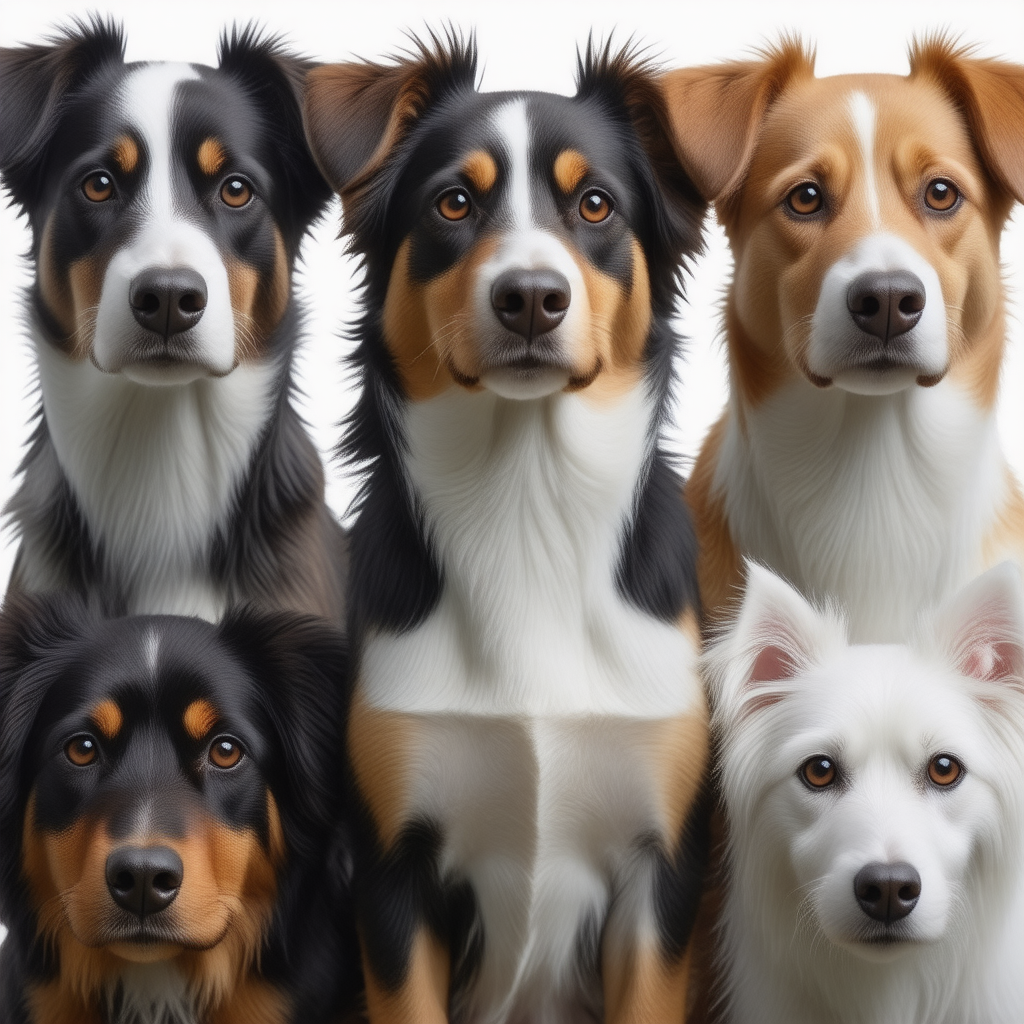

In [210]:
(
    pos_prompt_embeds,
    _,
    pos_pooled_prompt_embeds,
    _,
) = pipe.encode_prompt(
    prompt="a group of pet with different colors",
    prompt_2="a group of pet with different colors",
    prompt_3="a group of pet with different colors",
    max_sequence_length = 77
)

neg_prompt = "orange cat"

(
    neg_prompt_embeds,
    _,
    neg_pooled_prompt_embeds,
    _,
) = pipe.encode_prompt(
    prompt=neg_prompt,
    prompt_2=neg_prompt,
    prompt_3=neg_prompt,
    max_sequence_length = 77
)


negative_prompt_length = [len(pipe.tokenizer(neg_prompt).input_ids), len(pipe.tokenizer_3(neg_prompt).input_ids)]
# prompt_embeds = torch.cat([pos_prompt_embeds], dim=1)
prompt_embeds = torch.cat([pos_prompt_embeds, neg_prompt_embeds], dim=1)

image = pipe(
    prompt_embeds=prompt_embeds,
    pooled_prompt_embeds=pos_pooled_prompt_embeds,# - neg_pooled_prompt_embeds * 0.8,
    num_inference_steps=4,
    guidance_scale=0.0,
    generator=torch.manual_seed(0),
).images[0]
image

In [211]:
negative_prompt_length

[4, 3]